# Analyzing a Real-World Dataset with SQL and Python

## Objective
In this lab, I will:
- Load a real-world dataset into a SQLite database
- Query the data using SQL
- Answer analysis questions about the dataset
- Visualize the relationship between income and hardship index

This lab uses a real-world Chicago socioeconomic dataset and combines SQL and Python for analysis and visualization.

## Dataset Overview

This dataset contains selected socioeconomic indicators for community areas in Chicago.

The data includes variables such as:
- Community area name
- Percent of housing crowded
- Percent below poverty
- Percent aged 16+ unemployed
- Percent aged 25+ without high school diploma
- Percent aged under 18 or over 64
- Per capita income
- Hardship index

These indicators help analyze economic conditions across different community areas.

## Step 1: Set Up the Environment

In this step, I install and load the tools needed to use SQL inside the notebook.

In [1]:
!pip install ipython-sql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.3 MB/s eta 0:00:00


In [2]:
%load_ext sql

## Step 2: Import Required Libraries

I import pandas for data handling and visualization libraries for plotting.

In [3]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

## Step 3: Connect to the Database

Now I connect to a SQLite database where the dataset will be stored.

In [4]:
conn = sqlite3.connect("socioeconomic.db")

In [5]:
%sql sqlite:///socioeconomic.db

## Step 4: Load the Dataset into Pandas

I load the Chicago socioeconomic dataset from an online CSV file into a pandas DataFrame.

In [19]:
df = pd.read_csv("https://data.cityofchicago.org/resource/kn9c-c2s2.csv")
df.head()
df.rename(columns={"per_capita_income_": "per_capita_income"}, inplace=True)

## Step 5: Store the Dataset as a Table

Now I store the dataset in the SQLite database as a table called `chicago_socioeconomic_data`.

In [7]:
df.to_sql("chicago_socioeconomic_data", conn, if_exists="replace", index=False)

78

## Step 6: Verify the Table

I use Python to read the first 5 rows from the SQLite table and confirm that the data was stored successfully.

In [9]:
query = "SELECT * FROM chicago_socioeconomic_data LIMIT 5;"
pd.read_sql_query(query, conn)

,ca,community_area_name,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income_,hardship_index
0,1.0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0
1,2.0,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0
2,3.0,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0
3,4.0,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0
4,5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0


## Data Analysis Using SQL

The following queries explore patterns and insights in the dataset.

## Problem 1: How many rows are in the dataset?

In [10]:
query = "SELECT COUNT(*) AS total_rows FROM chicago_socioeconomic_data;"
pd.read_sql_query(query, conn)

,total_rows
0,78


## Problem 2: How many community areas in Chicago have a hardship index greater than 50?

In [11]:
query = """
SELECT COUNT(*) AS hardship_over_50
FROM chicago_socioeconomic_data
WHERE hardship_index > 50;
"""
pd.read_sql_query(query, conn)

,hardship_over_50
0,38


**Insight:** This shows how many community areas are experiencing relatively high socioeconomic hardship.

## Problem 3: What is the maximum value of hardship index in this dataset?

In [12]:
query = """
SELECT MAX(hardship_index) AS max_hardship_index
FROM chicago_socioeconomic_data;
"""
pd.read_sql_query(query, conn)

,max_hardship_index
0,98.0


## Problem 4: Which community area has the highest hardship index?

In [13]:
query = """
SELECT community_area_name, hardship_index
FROM chicago_socioeconomic_data
ORDER BY hardship_index DESC
LIMIT 1;
"""
pd.read_sql_query(query, conn)

,community_area_name,hardship_index
0,Riverdale,98.0


**Insight:** This identifies the community area facing the greatest socioeconomic challenges.

## Problem 5: Which Chicago community areas have per-capita incomes greater than $60,000?

In [15]:
query = """
SELECT community_area_name, per_capita_income_
FROM chicago_socioeconomic_data
WHERE per_capita_income_ > 60000;
"""
pd.read_sql_query(query, conn)

,community_area_name,per_capita_income_
0,Lake View,60058
1,Lincoln Park,71551
2,Near North Side,88669
3,Loop,65526


**Insight:** These are the highest-income community areas in the dataset.

## Prepare Data for Visualization

Before creating the chart, I convert the relevant columns to numeric format.

In [17]:
df["per_capita_income_"] = pd.to_numeric(df["per_capita_income_"], errors="coerce")
df["hardship_index"] = pd.to_numeric(df["hardship_index"], errors="coerce")

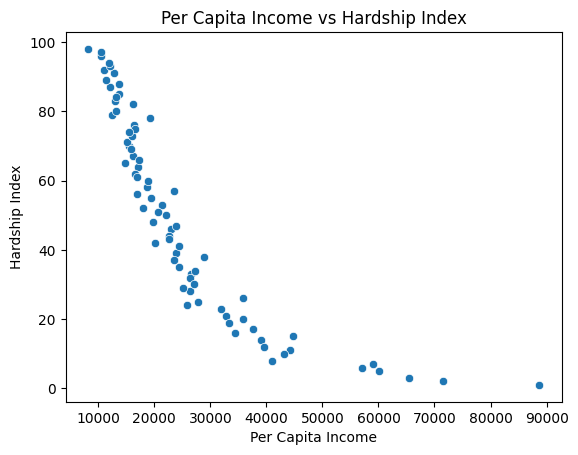

In [18]:
sns.scatterplot(
    x=df["per_capita_income_"],
    y=df["hardship_index"]
)

plt.title("Per Capita Income vs Hardship Index")
plt.xlabel("Per Capita Income")
plt.ylabel("Hardship Index")
plt.show()

## Conclusion

In this project, I analyzed a real-world Chicago socioeconomic dataset using SQL and Python.

I used SQL to query and explore key indicators such as income and hardship across community areas, and Python to visualize the relationship between these variables.

The analysis revealed a clear inverse relationship between per capita income and hardship index, suggesting that higher-income communities tend to experience lower levels of socioeconomic hardship.

This project highlights the value of combining SQL and Python to transform raw data into actionable insights and supports data-driven decision-making.